In [1]:
import h5py
import numpy as np
import pandas as pd
from scipy.fft import rfft, rfftfreq
from scipy.signal import butter, filtfilt, iirnotch, hilbert
from scipy.ndimage import uniform_filter1d, gaussian_filter1d
from collections import defaultdict
from pathlib import Path
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotnine import ggplot, aes, geom_line, geom_smooth, facet_grid, facet_wrap, theme

# ---------- EMG I/O & Preprocessing ----------
def reademg(
    filename: str,
    device: str = "98:D3:C1:FE:04:75",
    lowcut:float = 10.0,
    highcut:float = 450.0,
    fs: int = 1000
) -> pd.DataFrame:
    """Load raw EMG from H5 and apply bandpass + notch filtering."""
    with h5py.File(filename, "r") as f:
        raw = f[device]["raw"]
        data = {f"a{i}": raw[f"channel_{i}"][:, 0] for i in range(1, 5)}
    df = pd.DataFrame(data)
    df["ts"] = np.arange(len(df)) / fs
    return preprocess_emg(
        df,
        lowcut=lowcut,
        highcut=highcut,
        fs=fs,
    )

def bandpass_filter(sig: np.ndarray, lowcut:float, highcut: float, fs:float = 1000.0, order=4) -> np.ndarray:
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype="band")
    return filtfilt(b, a, sig)

def notch_filter(sig: np.ndarray, freq=60, fs=1000, Q=30) -> np.ndarray:
    w0 = freq / (fs/2)
    b, a = iirnotch(w0, Q)
    return filtfilt(b, a, sig)

def preprocess_emg(df: pd.DataFrame, lowcut: float, highcut: float, fs: int = 1000) -> pd.DataFrame:
    """Apply bandpass and notch filters to each EMG channel."""
    out = df.copy()
    for ch in ['a1', 'a2', 'a3', 'a4']:
        sig = out[ch].values
        out[ch] = notch_filter(bandpass_filter(sig, fs=fs, lowcut=lowcut, highcut=highcut), fs=fs)
    return out

def add_hilbert_envelopes(
    df,
    columns=["a1", "a2", "a3", "a4"],
    suffix="_env",
    inplace=False,
    smooth_method=None,
    smooth_params=None,
):

    # Work on copy if not inplace
    result_df = df if inplace else df.copy()

    # Add envelope columns
    for col in columns:
        if col not in result_df.columns:
            print(f"Warning: Column '{col}' not found in dataframe")
            continue

        # Compute Hilbert transform and envelope
        analytic_signal = hilbert(result_df[col])
        envelope = np.abs(analytic_signal)

        # Apply smoothing if specified
        if smooth_method is not None:
            envelope = smooth_envelope(
                envelope, method=smooth_method, params=smooth_params
            )

        # Add new column
        result_df[f"{col}{suffix}"] = envelope

    return result_df

def smooth_envelope(envelope, method="moving_avg", params=None):
    if params is None:
        params = {}

    if method == "moving_avg":
        window = params.get("window", 10)
        smoothed = pd.Series(envelope).rolling(window=window, center=True).mean()
        # Fill NaN values with original envelope values
        return smoothed.fillna(method="bfill").fillna(method="ffill").values

    elif method == "gaussian":
        sigma = params.get("sigma", 100.0)
        return gaussian_filter1d(envelope, sigma)

    else:
        raise ValueError(f"Unknown smoothing method: {method}")


def add_smoothed_envelopes(
    df, columns=["a1", "a2", "a3", "a4"], method="gaussian", inplace=False
):
    result_df = df if inplace else df.copy()

    for col in columns:
        if col not in result_df.columns:
            continue

        # First add raw envelope
        analytic_signal = hilbert(result_df[col])
        raw_envelope = np.abs(analytic_signal)
        # result_df[f'{col}_envelope_raw'] = raw_envelope

        # Add smoothed versions
        if method == "moving_avg":
            smoothed = smooth_envelope(raw_envelope, "moving_avg", {"window": 20})
        elif method == "savgol":
            smoothed = smooth_envelope(
                raw_envelope, "savgol", {"window_length": 21, "polyorder": 3}
            )
        elif method == "gaussian":
            smoothed = smooth_envelope(raw_envelope, "gaussian", {"sigma": 3.0})

        result_df[f"{col}_env"] = np.log10(smoothed + 1e-3)
    return result_df

def extend_timeline(timeline, target_length):
    """Minimal code to extend timeline using pattern analysis"""
    if len(timeline) >= target_length:
        return timeline[:target_length]

    # First, replace -1 with preceding event (default to 0)
    timeline_cleaned = timeline.copy()
    for i in range(len(timeline_cleaned)):
        if timeline_cleaned[i] == -1:
            if i > 0:
                timeline_cleaned[i] = timeline_cleaned[i - 1]
            else:
                timeline_cleaned[i] = 0

    # Analyze event durations
    event_durations = defaultdict(list)
    current_event = timeline_cleaned[0]
    current_duration = 1

    for i in range(1, len(timeline_cleaned)):
        if timeline_cleaned[i] == current_event:
            current_duration += 1
        else:
            event_durations[current_event].append(current_duration)
            current_event = timeline_cleaned[i]
            current_duration = 1

    # Calculate average durations
    avg_durations = {
        event: int(np.mean(durations)) for event, durations in event_durations.items()
    }

    #
    extended = timeline_cleaned.copy()
    sequence = [0, 1, 0, 2, 0, 3, 0, 4, 0, 5]
    last_event = extended[-1]

    # Find current position in sequence
    try:
        last_idx = (
            len(sequence) - 1 - sequence[::-1].index(last_event)
        )  # Find last occurrence
        next_idx = (last_idx + 1) % len(sequence)
    except ValueError:
        next_idx = 0  # Start from beginning if last event not found

    while len(extended) < target_length:
        next_event = sequence[next_idx]
        duration = min(
            avg_durations.get(next_event, 1000), target_length - len(extended)
        )
        extended = np.concatenate([extended, np.full(duration, next_event)])
        next_idx = (next_idx + 1) % len(sequence)

    return extended


def add_session_info(group):
    """
    Assigns:
        - 'session': session number based on event==1..5 structure
        - 'session_ts': time since session start (event==1)
        - 'session_event_ts': time since first occurrence of each event type in session
    """
    group = group.reset_index(drop=True)
    group["session"] = 0
    group["session_ts"] = 0.0
    group["session_event_ts"] = np.nan

    events = group["event"].values
    ts = group["ts"].values
    n = len(events)

    is_start_event = events == 1
    is_end_event = events == 5

    if not np.any(is_start_event) or not np.any(is_end_event):
        return group

    # Detect contiguous 1 blocks (rising edge)
    diff = np.diff(np.concatenate(([0], is_start_event.astype(int))))
    session_starts = np.where(diff == 1)[0]
    idx_end_all = np.where(is_end_event)[0]

    session_num = 1
    for i, start in enumerate(session_starts):
        next_start = session_starts[i + 1] if i + 1 < len(session_starts) else n
        end_candidates = idx_end_all[(idx_end_all > start) & (idx_end_all < next_start)]
        if len(end_candidates) == 0:
            continue

        end = end_candidates[-1]

        # Assign session and session_ts
        group.loc[start:end, "session"] = session_num
        group.loc[start:end, "session_ts"] = ts[start : end + 1] - ts[start]

        # Assign session_event_ts per event type
        session_slice = group.loc[start:end]
        for event_type in np.unique(session_slice["event"]):
            event_mask = (group["session"] == session_num) & (
                group["event"] == event_type
            )
            first_ts = group.loc[event_mask, "ts"].iloc[0]
            group.loc[event_mask, "session_event_ts"] = (
                group.loc[event_mask, "ts"] - first_ts
            )

        session_num += 1

    return group


def downsample_df(df, n=10):
    """
    Retains every nth row within each group defined by the trial column.

    Parameters:
        df (pd.DataFrame): Input DataFrame with a trial column.
        n (int): Keep every n-th row.

    Returns:
        pd.DataFrame: Filtered DataFrame with every n-th row per trial.
    """
    return (
        df.groupby("trial", group_keys=False)
        .apply(lambda g: g.iloc[::n])
        .reset_index(drop=True)
    )


def wide_to_tall(df):
    """
    Converts a wide EMG DataFrame to tall format with columns:
    trial, ts, event, session, session_ts, session_event_ts, channel, signal, env
    """
    import pandas as pd

    # Identify signal and env columns
    signal_cols = [
        col for col in df.columns if col.startswith("a") and not col.endswith("_env")
    ]
    env_cols = [f"{col}_env" for col in signal_cols]

    id_vars = ["trial", "ts", "event", "session", "session_ts", "session_event_ts"]

    # Melt signal and env data separately
    df_signal = df.melt(
        id_vars=id_vars, value_vars=signal_cols, var_name="channel", value_name="signal"
    )

    df_env = df.melt(
        id_vars=id_vars, value_vars=env_cols, var_name="channel_env", value_name="env"
    )

    # Normalize channel names for matching
    df_signal["channel"] = df_signal["channel"].str.strip()
    df_env["channel"] = df_env["channel_env"].str.replace("_env", "").str.strip()

    # Merge both melted frames on id_vars + channel
    df_merged = pd.merge(
        df_signal,
        df_env[id_vars + ["channel", "env"]],
        on=id_vars + ["channel"],
        how="left",
    )

    return df_merged


def extract_features_from_segment(signal, baseline_stats=None, fs=1000, window_sec=3):
    """Extract features from a window_sec-second segment with optional baseline normalization.

    Parameters:
    signal: EMG signal array
    baseline_stats: (mean, std) tuple for signal normalization, or None to skip normalization
    fs: Sampling frequency (default 1000 Hz)
    window_sec: Window duration in seconds (default 3)
    """
    n = len(signal)
    target_len = window_sec * fs
    if n < target_len:  # pad if incomplete
        signal = np.pad(signal, (0, target_len - n), "constant")
        n = len(signal)

    # time-domain features over 100ms windows
    win = fs // 10
    n_windows = n // win
    feats = {"rms": [], "mav": [], "wl": [], "zc": []}
    for i in range(n_windows):
        seg = signal[i * win : (i + 1) * win]
        feats["rms"].append(np.sqrt(np.mean(seg**2)))
        feats["mav"].append(np.mean(np.abs(seg)))
        feats["wl"].append(np.sum(np.abs(np.diff(seg))))
        crosses = np.where(np.diff(np.sign(seg)))[0]
        feats["zc"].append(
            np.sum(np.abs(np.diff(seg)[crosses]) > 0.01) if crosses.size else 0
        )
    avg_feats = {k: np.mean(v) for k, v in feats.items()}

    # frequency-domain (full window)
    freqs = rfftfreq(n, 1 / fs)

    # Apply signal normalization if baseline_stats provided#i DO NOT NORMALIZE BEFORE ITS OFF!  
    if baseline_stats is not None:
        mean0, std0 = baseline_stats
        norm_sig = (signal - mean0) / (std0 + 1e-8)
    else:
        norm_sig = signal

    fft_vals = rfft(norm_sig * np.hamming(n))
    power = np.abs(fft_vals) ** 2

    # bands
    bands = {
        "beta": (13, 30),
        "gamm1": (30, 100),
        "gamma2": (100, 250),
        "gamma3": (250, 450),
    }
    for name, (lo, hi) in bands.items():
        mask = (freqs >= lo) & (freqs <= hi)
        avg_feats[name] = np.mean(power[mask]) if mask.any() else 0

    


    return avg_feats


def extract_features_from_multi_column_segment(
    segment_data,
    emg_columns=["a1", "a2", "a3", "a4"],
    baseline_stats=None,
    fs=1000,
    window_sec=3,
):
    """Extract features from multiple EMG columns in a segment.

    Parameters:
    segment_data: DataFrame with EMG columns
    emg_columns: List of EMG column names (default ['a1', 'a2', 'a3', 'a4'])
    baseline_stats: Dict with column names as keys and (mean, std) tuples as values, or None
    fs: Sampling frequency (default 1000 Hz)
    window_sec: Window duration in seconds (default 3)

    Returns:
    Dictionary with features for all columns
    """
    all_features = {}

    for col in emg_columns:
        if col not in segment_data.columns:
            continue

        # Get signal for this column
        signal = segment_data[col].values

        # Get baseline stats for this column if available
        col_baseline_stats = None
        if baseline_stats is not None and col in baseline_stats:
            col_baseline_stats = baseline_stats[col]

        # Extract features for this column
        features = extract_features_from_segment(
            signal, col_baseline_stats, fs=fs, window_sec=window_sec
        )

        # Add column prefix to feature names
        for feat_name, feat_value in features.items():
            all_features[f"{col}_{feat_name}"] = feat_value

    return all_features


def process_emg_features(
    df,
    trial_col="trial",
    emg_columns=["a1", "a2", "a3", "a4"],
    fs=1000,
    normalize_signal=False,
    include_raw_features=True,
    raw_features_to_include=['wl', 'zc'],
    standardize_features=True,
):
    """
    Process EMG features for all trials and sessions with event-based time windows and normalization.
    WL and ZC features are excluded from baseline normalization.
    
    NORMALIZATION METHODS (Scientifically Supported):
    - MAV & RMS (amplitude features): Uses relative change normalization: (activity - baseline) / baseline
      This follows EMG literature principles where baseline muscle activity is subtracted to isolate
      task-related activation changes, then scaled by baseline to account for individual differences.
    - Frequency features: Uses ratio normalization: activity / baseline
      This preserves relative power changes across frequency bands while controlling for individual
      baseline power differences.

    Parameters:
    df: DataFrame with columns ['trial', 'session', 'ts', 'a1', 'a2', 'a3', 'a4', 'event', 'session_event_ts']
    trial_col: Name of the trial column (default 'trial')
    emg_columns: List of EMG column names (default ['a1', 'a2', 'a3', 'a4'])
    fs: Sampling frequency (default 1000 Hz)
    normalize_signal: Whether to apply signal-level normalization before frequency analysis (default True)
    include_raw_features: Whether to include any raw features in output (default True)
    raw_features_to_include: List of feature types to include as raw features. If None, includes all.
                            Options: ['mav', 'rms', 'wl', 'zc', 'beta', 'gamm1', 'gamma2', 'gamma3', 'smooth_log_power']
                            If include_raw_features=False, this parameter is ignored.
    standardize_features: Whether to standardize features within each trial (default False)

    Returns:
    DataFrame with extracted and normalized features (WL and ZC excluded from baseline normalization)
    """
    results = []
    
    # Define features that should NOT be baseline normalized
    no_baseline_norm_features = ['wl', 'zc']
    
    # Set default raw features to include if not specified
    if raw_features_to_include is None:
        raw_features_to_include = ['mav', 'rms', 'wl', 'zc', 'beta', 'gamm1', 'gamma2', 'gamma3', ]

    # Process each trial separately
    for trial_id in df[trial_col].unique():
        trial_data = df[df[trial_col] == trial_id].copy()
        print(f"Processing trial {trial_id}...")

        # Process each session within the trial
        for session_id in trial_data["session"].unique():
            session_data = trial_data[trial_data["session"] == session_id].copy()
            session_data = session_data.sort_values(["ts"]).reset_index(drop=True)

            # Get unique events in order for this session
            events = session_data["event"].unique()

            # Store baseline features for normalization
            baseline_features = {}

            for event_id in sorted(events):
                event_data = session_data[session_data["event"] == event_id].copy()

                if len(event_data) == 0:
                    continue

                # Calculate baseline stats for each EMG column (for signal normalization)
                baseline_stats = None
                if normalize_signal:
                    baseline_stats = {}
                    for col in emg_columns:
                        if col in event_data.columns:
                            baseline_stats[col] = (
                                event_data[col].mean(),
                                event_data[col].std(),
                            )

                if event_id == 0:
                    # For event 0: use last 2 seconds
                    max_event_ts = event_data["session_event_ts"].max()
                    time_threshold = max(0, max_event_ts - 2)
                    segment_data = event_data[
                        event_data["session_event_ts"] >= time_threshold
                    ]
                    window_sec = 2

                else:
                    # For non-zero events: use first 3 seconds
                    segment_data = event_data[event_data["session_event_ts"] <= 3]
                    window_sec = 3

                if len(segment_data) == 0:
                    continue

                # Extract features from all EMG columns
                features = extract_features_from_multi_column_segment(
                    segment_data,
                    emg_columns,
                    baseline_stats,
                    fs=fs,
                    window_sec=window_sec,
                )
                features.pop("smooth_log_power", None)
                # Store baseline features (event 0) for normalization
                if event_id == 0:
                    baseline_features = features.copy()

                # Create result record
                result = {
                    "trial": trial_id,
                    "session": session_id,
                    "event": event_id,
                    "n_samples": len(segment_data),
                    "time_window": f"{'last_2s' if event_id == 0 else 'first_3s'}",
                }

                # Add raw features (selective based on raw_features_to_include)
                if include_raw_features:
                    for feat_name, feat_value in features.items():
                        # Check if this feature type should be included as raw
                        feature_type = feat_name.split('_')[-1]  # Get the feature type (e.g., 'mav', 'rms', etc.)
                        if feature_type in raw_features_to_include:
                            result[f"raw_{feat_name}"] = feat_value

                # Add normalized features for non-zero events (excluding WL and ZC)
                if event_id != 0 and baseline_features:
                    for feat_name, feat_value in features.items():
                        # Check if this feature should skip baseline normalization
                        should_skip_baseline_norm = any(
                            no_norm_feat in feat_name.lower() 
                            for no_norm_feat in no_baseline_norm_features
                        )
                        
                        if not should_skip_baseline_norm:
                            baseline_value = baseline_features.get(feat_name, 1.0)
                            
                            # Apply scientifically supported normalization methods
                            if any(amplitude_feat in feat_name.lower() for amplitude_feat in ['mav', 'rms']):
                                # For amplitude features (MAV, RMS): Use baseline subtraction + scaling
                                # This follows the principle: normalized = (activity - baseline) / baseline
                                # This gives relative change from baseline, commonly used in EMG research
                                if baseline_value > 1e-8:  # Avoid division by very small numbers
                                    result[f"norm_{feat_name}"] = (feat_value - baseline_value) / baseline_value
                                else:
                                    result[f"norm_{feat_name}"] = 0.0
                            else:
                                # For frequency features: Use simple ratio normalization
                                # This preserves relative power changes across frequency bands
                                if baseline_value != 0:
                                    result[f"norm_{feat_name}"] = feat_value / baseline_value
                                else:
                                    result[f"norm_{feat_name}"] = feat_value
                        # For WL and ZC, we don't create normalized versions
                        
                elif event_id != 0:
                    # If no baseline available, set normalized features to NaN (excluding WL and ZC)
                    for feat_name in features.keys():
                        should_skip_baseline_norm = any(
                            no_norm_feat in feat_name.lower() 
                            for no_norm_feat in no_baseline_norm_features
                        )
                        
                        if not should_skip_baseline_norm:
                            result[f"norm_{feat_name}"] = np.nan

                results.append(result)

    # Convert to DataFrame
    df_results = pd.DataFrame(results)

    # Apply feature standardization if requested
    if standardize_features and len(df_results) > 0:
        df_results = _standardize_features_within_trial(df_results)

    return df_results

def _standardize_features_within_trial(df_results, epsilon=1e-8):
    """
    Standardize features within each trial across all sessions and events.
    Applies log transformation before standardization to handle skewed distributions,
    but skips log transformation for mav, rms, wl, zc features.
    Modifies existing feature columns in-place and multiplies standardized values by 10.

    Parameters:
    df_results: DataFrame with features from process_emg_features
    epsilon: Small constant added before log transformation to ensure positive values

    Returns:
    DataFrame with selectively log-transformed, standardized, and scaled features
    """
    import numpy as np
    import pandas as pd

    # Identify feature columns (exclude identifier columns)
    id_cols = ["trial", "session", "event", "n_samples", "time_window"]
    feature_cols = [col for col in df_results.columns if col not in id_cols]

    # Define features that should NOT be log-transformed
    no_log_features = ['mav', 'rms', 'wl', 'zc']

    # Create a copy to avoid modifying original
    df_standardized = df_results.copy()

    # Apply selective log transformation to feature values
    for feat_col in feature_cols:
        # Check if this feature should skip log transformation
        should_skip_log = any(no_log_feat in feat_col.lower() for no_log_feat in no_log_features)
        
        if not should_skip_log:
            # Apply log transformation for features not in the skip list
            df_standardized[feat_col] = np.log(df_standardized[feat_col] + epsilon)

    # Group by trial
    for trial_id, group in df_standardized.groupby(["trial"]):
        if len(group) <= 1:
            continue

        for feat_col in feature_cols:
            values = group[feat_col].dropna()

            if len(values) > 1:
                feat_mean = values.mean()
                feat_std = values.std()

                mask = df_standardized["trial"] == trial_id
                if feat_std > 0:
                    df_standardized.loc[mask, feat_col] = (
                        (df_standardized.loc[mask, feat_col] - feat_mean) / feat_std
                    ) * 10.0  # Multiply by 10
                else:
                    df_standardized.loc[mask, feat_col] = 0.0

    return df_standardized


def melt_emg_features(features_df):
    """
    Convert wide EMG features DataFrame to tall format with separate channel and feature columns.

    Parameters:
    features_df: DataFrame returned by process_emg_features()

    Returns:
    DataFrame in tall format with columns: trial, session, event, n_samples, time_window, channel, feature, value
    """
    # Identify identifier columns (non-feature columns)
    id_cols = ["trial", "session", "event", "n_samples", "time_window"]

    # Get feature columns (all columns except identifiers)
    feature_cols = [col for col in features_df.columns if col not in id_cols]

    # Melt the dataframe
    melted_df = pd.melt(
        features_df,
        id_vars=id_cols,
        value_vars=feature_cols,
        var_name="feature",
        value_name="value",
    )

    # Extract channel and feature type from the feature column
    # Feature format: {prefix}_{channel}_{feature_name}
    # e.g., "raw_a1_rms" -> prefix="raw", channel="a1", feature_name="rms"
    def parse_feature_name(feature_name):
        parts = feature_name.split("_")
        if len(parts) >= 3:
            prefix = parts[0]  # raw or norm
            channel = parts[1]  # a1, a2, a3, a4
            feature_type = "_".join(parts[2:])  # rms, mav, fft_beta, etc.
            return prefix, channel, feature_type
        else:
            # Handle edge cases where format might be different
            return "unknown", "unknown", feature_name

    # Parse feature names
    parsed_features = melted_df["feature"].apply(parse_feature_name)
    melted_df["prefix"] = [x[0] for x in parsed_features]
    melted_df["channel"] = [x[1] for x in parsed_features]
    melted_df["feature"] = [x[2] for x in parsed_features]

    # Reorder columns for better readability
    column_order = [
        "trial",
        "session",
        "event",
        "n_samples",
        "time_window",
        "channel",
        "prefix",
        "feature",
        "value",
    ]
    melted_df = melted_df[column_order]

    return melted_df



def plot_column_vs_ts(
    df,
    column,
    ts_column="ts",
    session_column="session",
    trial_column="trial",
    timeline_column="event",
    title=None,
    width=800,
    height=1200,
    ts_from=None,
    ts_to=None,
    show_timeline=True,
    show_sessions=True,
):
    # Basic checks
    for required_col in [column, ts_column, trial_column]:
        if required_col not in df.columns:
            raise ValueError(f"Column '{required_col}' not found in dataframe")

    if show_timeline and timeline_column not in df.columns:
        raise ValueError(f"Timeline column '{timeline_column}' not found in dataframe")

    if show_sessions and session_column not in df.columns:
        raise ValueError(f"Session column '{session_column}' not found in dataframe")

    # Filter by time if needed
    df_filtered = df.copy()
    if ts_from is not None:
        df_filtered = df_filtered[df_filtered[ts_column] >= ts_from]
    if ts_to is not None:
        df_filtered = df_filtered[df_filtered[ts_column] <= ts_to]

    trials = sorted(df_filtered[trial_column].unique())
    n_trials = len(trials)

    if title is None:
        title = f"{column} vs {ts_column} by Trial"
        if show_sessions:
            title += " (Sessions Shown as Step Function)"

    # Create subplots
    fig = make_subplots(
        rows=n_trials,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.08,
        subplot_titles=[f"Trial {trial}" for trial in trials],
        specs=[[{"secondary_y": True}] for _ in range(n_trials)],
    )

    for i, trial in enumerate(trials, start=1):
        trial_data = df_filtered[df_filtered[trial_column] == trial]

        # Main signal trace
        fig.add_trace(
            go.Scatter(
                x=trial_data[ts_column],
                y=trial_data[column],
                mode="lines",
                name=f"Trial {trial} - {column}" if i == 1 else None,
                line=dict(width=2),
                showlegend=(i == 1),
            ),
            row=i,
            col=1,
            secondary_y=False,
        )

        # Session step plot (if enabled)
        if show_sessions:
            fig.add_trace(
                go.Scatter(
                    x=trial_data[ts_column],
                    y=trial_data[session_column],
                    mode="lines",
                    name="Session (step)" if i == 1 else None,
                    line=dict(shape="hv", color="gray", width=1.5, dash="dot"),
                    showlegend=(i == 1),
                ),
                row=i,
                col=1,
                secondary_y=True,
            )

        # Timeline event trace (if enabled)
        if show_timeline:
            fig.add_trace(
                go.Scatter(
                    x=trial_data[ts_column],
                    y=trial_data[timeline_column],
                    mode="lines",
                    name="Timeline" if i == 1 else None,
                    line=dict(width=1, color="black"),
                    opacity=0.6,
                    showlegend=(i == 1),
                ),
                row=i,
                col=1,
                secondary_y=True,
            )

    # Layout
    fig.update_layout(
        title=title,
        width=width,
        height=height,
        template="plotly_white",
        legend=dict(yanchor="top", y=0.99, xanchor="left", x=1.02),
    )

    # Axes labels
    fig.update_xaxes(title_text=ts_column, row=n_trials, col=1)
    for i in range(1, n_trials + 1):
        fig.update_yaxes(title_text=column, row=i, col=1, secondary_y=False)
        if show_sessions or show_timeline:
            fig.update_yaxes(
                title_text="Session / Timeline", row=i, col=1, secondary_y=True
            )

    return fig

Opening: C:\Users\megab\Downloads\All EMG recordings\used\ShubProtocol2trial1.h5


C:\Users\megab\AppData\Local\Temp\ipykernel_11888\184340784.py:256: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


Opening: C:\Users\megab\Downloads\All EMG recordings\used\ShubProtocol2trial2.h5


C:\Users\megab\AppData\Local\Temp\ipykernel_11888\184340784.py:256: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


Opening: C:\Users\megab\Downloads\All EMG recordings\used\ShubProtocol2trial3.h5


C:\Users\megab\AppData\Local\Temp\ipykernel_11888\184340784.py:256: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
C:\Users\megab\AppData\Local\Temp\ipykernel_11888\1392702451.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


Processing trial 1...
Processing trial 2...
Processing trial 3...


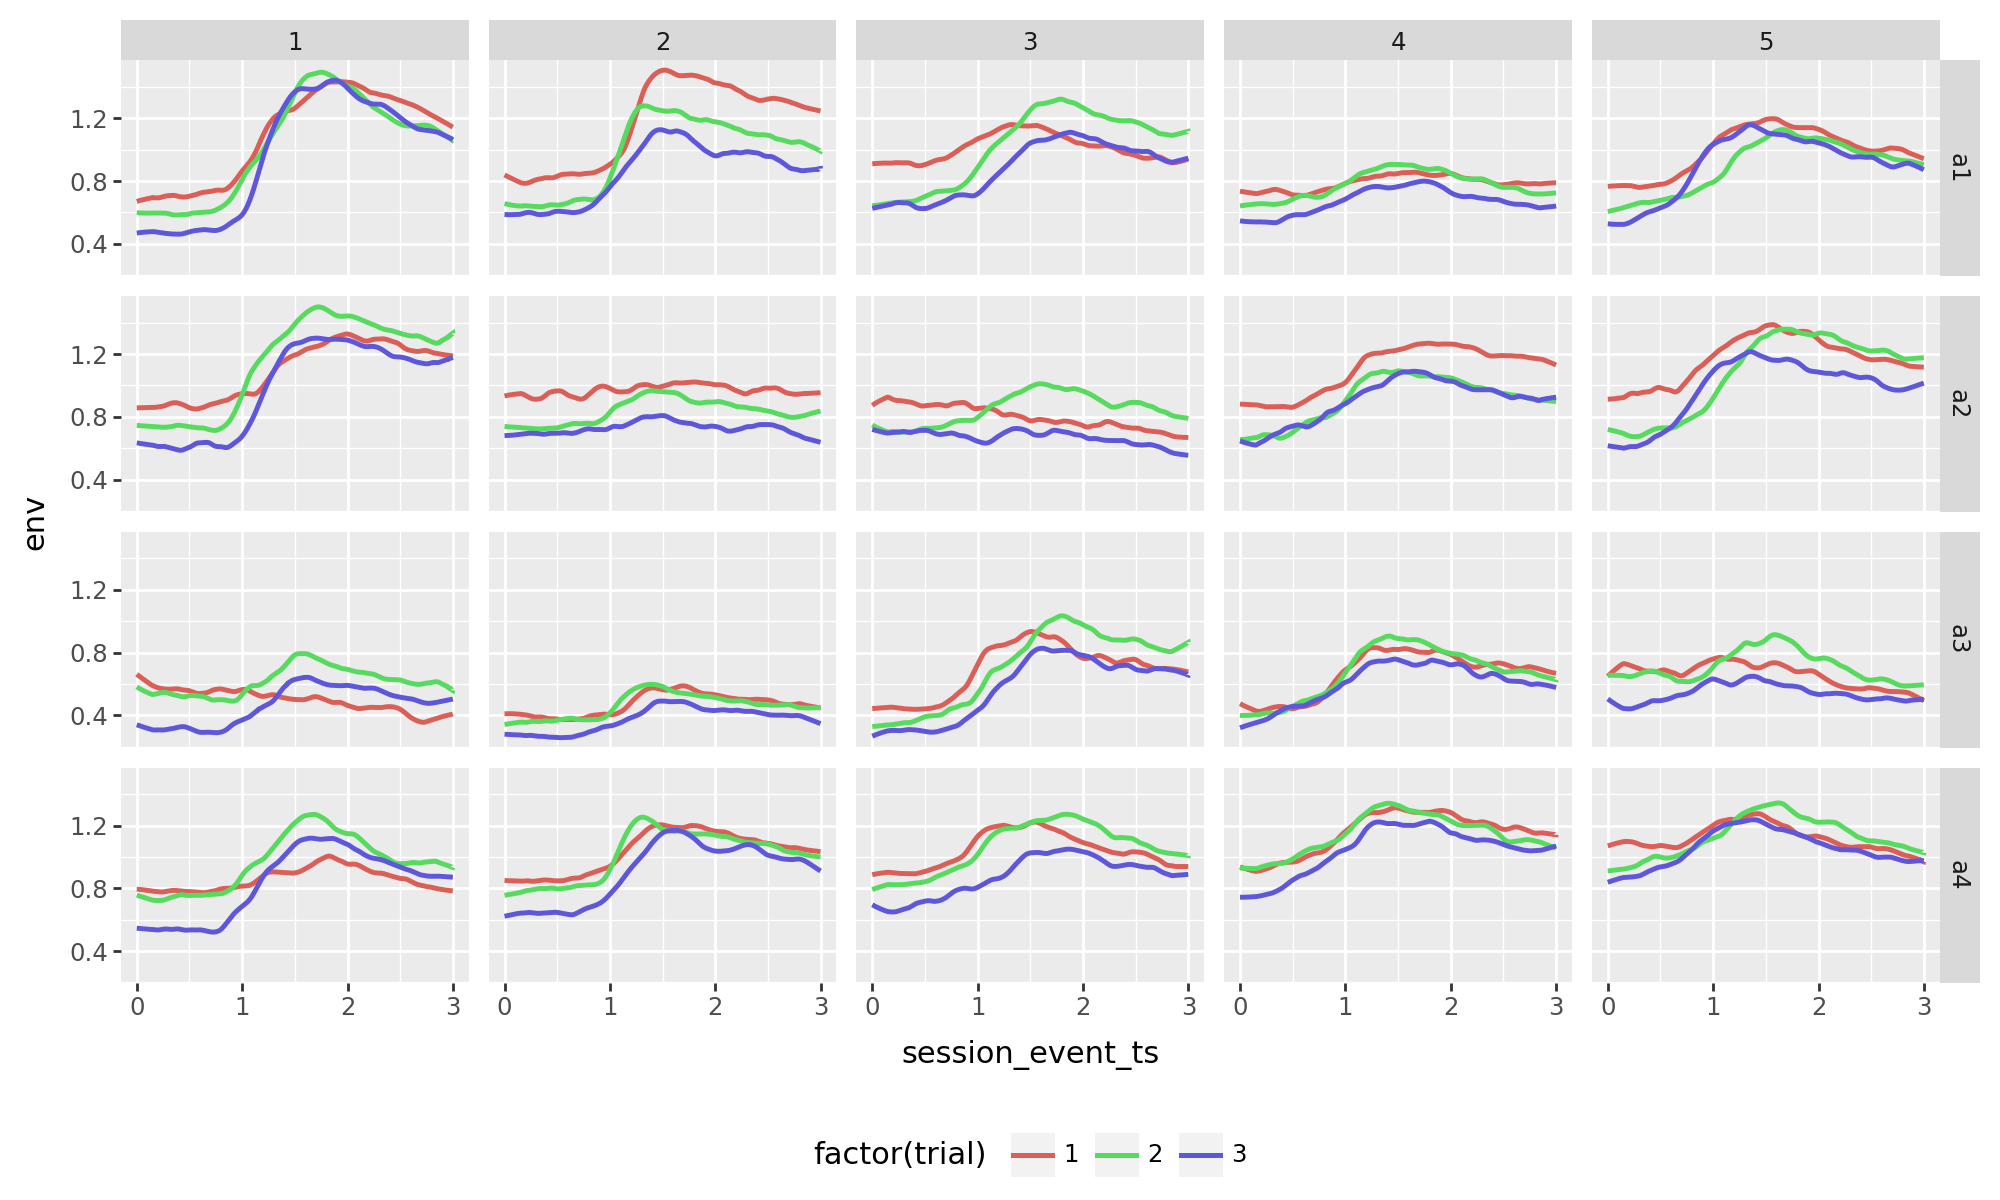

In [ ]:
input_dir = Path(r"yoursourcedatapath")
timeline_path = r"yourtimelimedatapath\indicators24Jun2025.npy"
timeline = np.load(timeline_path)

# REMOVE LEADING SLASHES from paths
emg_files = [
    
         "session1subject1data",
    "session2subject1data",
     "session3subject1data" , 

    
]
left_trim = [8.55,8.3,3.4]#start times for each protocol aligning with each respective session
bands = {
    'beta':   (13, 30),
    'gamma1':  (30, 100),
    'gamma2': (100, 250),
    'gamma3': (250, 450),
}
bandname = None

dfs = []
# Read all EMG files and combine into single dataframe with envelopes
for i, emg_file in enumerate(emg_files, 1):
    # CORRECTED PATH HANDLING
    full_path = input_dir / emg_file
    print(f"Opening: {full_path}")
    
    if not full_path.exists():
        raise FileNotFoundError(f" File not found: {full_path}")

    lowcut, highcut = (10, 450) if bandname is None else bands[bandname]
    df = reademg(str(full_path), lowcut=lowcut, highcut=highcut)  # Convert to string if needed
    df["trial"] = i
    trim_time = left_trim[i - 1]
    df = df[df["ts"] >= trim_time].reset_index(drop=True)

    # Reset ts column to start from 0
    if len(df) > 0:
        ts_offset = df["ts"].iloc[0]
        df["ts"] = df["ts"] - ts_offset

    # Add smoothed envelopes to each trial
    df = add_smoothed_envelopes(df, method="gaussian")

    # Add extended timeline for this trial
    extended_timeline = extend_timeline(timeline, df.shape[0])
    df["event"] = extended_timeline

    df = downsample_df(df,1)
    dfs.append(df)

# Combine all trials into single dataframe (already has envelopes)
df_final = pd.concat(dfs, ignore_index=True)
df_final = df_final.groupby("trial").apply(add_session_info).reset_index(drop=True)
features_df = process_emg_features(df_final)
df_filtered_tall = wide_to_tall(df_final)

(
    ggplot(
        df_filtered_tall[
            (df_filtered_tall["event"] != 0)
            & (df_filtered_tall["session_event_ts"] < 3.0)
            & (df_filtered_tall["session"] < 10)
        ],
        aes(x="session_event_ts", y="env", color="factor(trial)"),
    )
    # + geom_line()
    + geom_smooth(method="lowess", span=0.1, se=False)
    + facet_grid("channel~event")
    + theme(legend_position="bottom", figure_size=(10, 6))
)

In [ ]:
# plot_column_vs_ts(
#     df_filtered,
#     "a1_env",
#     height=600,
#     width=1000,
#     #ts_from=0,
#     #ts_to=200,
# )  # ts_from=0, ts_to=200,

In [ ]:
(
    ggplot(
        df_filtered_tall[
            (df_filtered_tall["channel"] == "a1")
            & (df_filtered_tall["event"] != 0)
            & (df_filtered_tall["session_event_ts"] < 3.0)
            & (df_filtered_tall["session"] < 10)
        ],
        aes(x="session_event_ts", y="env", color="factor(session)"),
    )
    # + geom_line()
    + geom_smooth(method="lowess", span=0.1, se=False)
    + facet_grid("trial~event")
    + theme(legend_position="bottom", figure_size=(10, 6))
)

In [ ]:
from plotnine import geom_boxplot


(
    ggplot(tall_features_df, aes(x="factor(feature)", y="value", color="factor(trial)"))
    #+ scale_y_log10()
    + geom_boxplot()
    + facet_grid("channel~event")
    + theme(legend_position="bottom", figure_size=(10, 6))
)

In [34]:
print(f"All available columns: {list(features_df.columns)}")

All available columns: ['trial', 'session', 'event', 'n_samples', 'time_window', 'raw_a1_wl', 'raw_a1_zc', 'raw_a2_wl', 'raw_a2_zc', 'raw_a3_wl', 'raw_a3_zc', 'raw_a4_wl', 'raw_a4_zc', 'norm_a1_rms', 'norm_a1_mav', 'norm_a1_beta', 'norm_a1_gamm1', 'norm_a1_gamma2', 'norm_a1_gamma3', 'norm_a1_smooth_log_power', 'norm_a2_rms', 'norm_a2_mav', 'norm_a2_beta', 'norm_a2_gamm1', 'norm_a2_gamma2', 'norm_a2_gamma3', 'norm_a2_smooth_log_power', 'norm_a3_rms', 'norm_a3_mav', 'norm_a3_beta', 'norm_a3_gamm1', 'norm_a3_gamma2', 'norm_a3_gamma3', 'norm_a3_smooth_log_power', 'norm_a4_rms', 'norm_a4_mav', 'norm_a4_beta', 'norm_a4_gamm1', 'norm_a4_gamma2', 'norm_a4_gamma3', 'norm_a4_smooth_log_power']


In [ ]:
# 6-Fold Stratified CV with equal gesture distribution this is our main across all sessions train on 80%, test on 20% 
#this works with 3 sessions or 6 sessions 
import os
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import train_test_split, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# 1) MLP Definition
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )
    
    def forward(self, x):
        return self.model(x)

# 2) Training Function
def train_mlp_with_loss_tracking(
    X_train, y_train,
    input_dim, output_dim,
    epochs=50, batch_size=128, lr=1e-3
):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = MLPClassifier(input_dim, output_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    
    ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long)
    )
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)
    
    train_losses = []
    for epoch in range(1, epochs + 1):
        running_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = loss_fn(preds, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg = running_loss / len(loader)
        train_losses.append(avg)
        if epoch % 10 == 0:
            print(f"  Epoch {epoch}/{epochs} — Loss: {avg:.4f}")
    return model, train_losses

# 3) Evaluation Function
def evaluate_mlp(model, X_test, y_test):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    with torch.no_grad():
        xb = torch.tensor(X_test, dtype=torch.float32).to(device)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)
    acc = accuracy_score(y_test, preds)
    try:
        auc = roc_auc_score(y_test, probs, multi_class='ovr', average='weighted')
    except ValueError:
        auc = np.nan
    return acc, auc, preds, probs

# 4) 6-Fold CV with Test Set (20% of total data)
def train_with_6fold_and_test(
    X, y, input_dim, n_classes,
    test_size=0.20, random_state=42, epochs=50, batch_size=128, lr=1e-3
):
    """
    Perform 6-fold stratified cross-validation with equal gesture distribution.
    
    Args:
        X: Feature matrix
        y: Labels (should have equal samples per gesture class)
        test_size: Proportion for test set (default 0.20 for ~30 samples out of 150)
        Other args: Training parameters
    """
    
    # Print initial data distribution
    unique_classes, class_counts = np.unique(y, return_counts=True)
    print(f"Initial data distribution:")
    for cls, count in zip(unique_classes, class_counts):
        print(f"  Gesture {cls}: {count} samples")
    print(f"Total samples: {len(y)}")
    
    # Split out test set (stratified to maintain equal gesture distribution)
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    
    print(f"\nAfter train/test split:")
    print(f"Train+Val: {len(X_trainval)} samples")
    print(f"Test: {len(X_test)} samples")
    
    # Check test set distribution
    test_unique, test_counts = np.unique(y_test, return_counts=True)
    print(f"Test set distribution:")
    for cls, count in zip(test_unique, test_counts):
        print(f"  Gesture {cls}: {count} samples")
    
    # 6-fold CV on the training+validation set
    skf = StratifiedKFold(n_splits=6, shuffle=True, random_state=random_state)
    fold_results = []
    fold_losses = []
    
    print(f"\n=== 6-FOLD CROSS-VALIDATION ===")
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
        print(f"\n--- Fold {fold} ---")
        X_tr, X_val = X_trainval[train_idx], X_trainval[val_idx]
        y_tr, y_val = y_trainval[train_idx], y_trainval[val_idx]
        
        # Check fold distribution
        val_unique, val_counts = np.unique(y_val, return_counts=True)
        print(f"Validation fold distribution: {dict(zip(val_unique, val_counts))}")
        
        model, losses = train_mlp_with_loss_tracking(
            X_tr, y_tr, input_dim, n_classes,
            epochs=epochs, batch_size=batch_size, lr=lr
        )
        fold_losses.append(losses)
        
        acc_v, auc_v, _, _ = evaluate_mlp(model, X_val, y_val)
        print(f"Fold {fold} Val — Acc: {acc_v:.3f}, AUC: {auc_v:.3f}")
        fold_results.append({'fold': fold, 'val_acc': acc_v, 'val_auc': auc_v})
    
    # Calculate CV statistics
    cv_accs = [r['val_acc'] for r in fold_results]
    cv_aucs = [r['val_auc'] for r in fold_results]
    
    print(f"\n=== CROSS-VALIDATION SUMMARY ===")
    print(f"Mean CV Accuracy: {np.mean(cv_accs):.3f} ± {np.std(cv_accs):.3f}")
    print(f"Mean CV AUC: {np.mean(cv_aucs):.3f} ± {np.std(cv_aucs):.3f}")
    
    best_fold = max(fold_results, key=lambda r: r['val_acc'])
    print(f"Best fold: {best_fold['fold']} (Val Acc {best_fold['val_acc']:.3f})")
    
    # Retrain on all train+val data for final test evaluation
    print(f"\n=== TRAINING FINAL MODEL ON ALL TRAIN+VAL DATA ===")
    final_model, final_losses = train_mlp_with_loss_tracking(
        X_trainval, y_trainval, input_dim, n_classes,
        epochs=epochs, batch_size=batch_size, lr=lr
    )
    
    # Evaluate on test set
    acc_test, auc_test, preds_test, probs_test = evaluate_mlp(final_model, X_test, y_test)
    
    print(f"\n=== FINAL TEST RESULTS ===")
    print(f"Test Accuracy: {acc_test:.3f}")
    print(f"Test AUC: {auc_test:.3f}")
    print("\nTest Set Classification Report:")
    print(classification_report(
        y_test, preds_test,
        target_names=[f"Gesture_{c}" for c in unique_classes]
    ))
    
    # Test set confusion matrix
    cm_test = confusion_matrix(y_test, preds_test)
    
    return {
        'fold_results': fold_results,
        'fold_losses': fold_losses,
        'cv_mean_acc': np.mean(cv_accs),
        'cv_std_acc': np.std(cv_accs),
        'cv_mean_auc': np.mean(cv_aucs),
        'cv_std_auc': np.std(cv_aucs),
        'test_acc': acc_test,
        'test_auc': auc_test,
        'test_cm': cm_test,
        'test_true': y_test,
        'test_pred': preds_test,
        'test_probs': probs_test,
        'final_model': final_model
    }

# 5) Complete Analysis Function
def complete_emg_analysis(features_df, feature_prefix='norm', random_state=42, 
                         test_size=0.20, epochs=50):
    """
    Complete EMG analysis with 6-fold CV and test evaluation.
    
    Args:
        features_df: DataFrame with EMG features
        feature_prefix: 'norm', 'raw', or 'both'
        test_size: Proportion for test set (0.20 = ~30 out of 150 samples)
    """
    
    # Select features based on prefix
    if feature_prefix == 'both':
        feature_cols = [c for c in features_df.columns if c.startswith(('norm_', 'raw_'))]
    else:
        feature_cols = [c for c in features_df.columns if c.startswith(f'{feature_prefix}_')]
    
    print(f"Selected {len(feature_cols)} features with prefix '{feature_prefix}'")
    
    # Prepare data (exclude event 0 - baseline)
    df = features_df[features_df['event'] != 0].copy()
    X = df[feature_cols].fillna(0).to_numpy()
    
    # Encode labels
    le = LabelEncoder()
    y = le.fit_transform(df['event'].values)
    
    print(f"Training on {X.shape[1]} features with {X.shape[0]} samples")
    print(f"Gesture classes: {le.classes_}")
    
    # Run 6-fold CV with test evaluation
    results = train_with_6fold_and_test(
        X, y,
        input_dim=X.shape[1],
        n_classes=len(le.classes_),
        test_size=test_size,
        random_state=random_state,
        epochs=epochs
    )
    
    # Plot average training loss across folds
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    avg_losses = np.mean(results['fold_losses'], axis=0)
    std_losses = np.std(results['fold_losses'], axis=0)
    epochs_range = np.arange(1, len(avg_losses) + 1)
    
    plt.plot(epochs_range, avg_losses, 'b-', label='Mean')
    plt.fill_between(epochs_range, 
                     avg_losses - std_losses, 
                     avg_losses + std_losses, 
                     alpha=0.2, color='blue', label='±1 std')
    plt.xlabel("Epoch")
    plt.ylabel("Cross-Entropy Loss")
    plt.title("6-Fold CV: Average Training Loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Plot test confusion matrix
    plt.subplot(1, 2, 2)
    cm = results['test_cm']
    classes = le.classes_
    pct = cm.astype(float) / cm.sum(axis=1)[:, None] * 100
    
    annot = np.empty_like(cm).astype(str)
    for i in range(len(classes)):
        for j in range(len(classes)):
            annot[i, j] = f"{cm[i, j]}\n({pct[i, j]:.0f}%)"
    
    sns.heatmap(pct, annot=annot, fmt="", cmap="Blues",
                xticklabels=[f"G{c}" for c in classes], 
                yticklabels=[f"G{c}" for c in classes],
                cbar_kws={'label': '% of true'})
    plt.title(f"Test Confusion Matrix\nAcc: {results['test_acc']:.1%}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n=== FINAL SUMMARY ===")
    print(f"6-Fold CV Accuracy: {results['cv_mean_acc']:.3f} ± {results['cv_std_acc']:.3f}")
    print(f"6-Fold CV AUC: {results['cv_mean_auc']:.3f} ± {results['cv_std_auc']:.3f}")
    print(f"Test Accuracy: {results['test_acc']:.3f}")
    print(f"Test AUC: {results['test_auc']:.3f}")
    
    return results

# 6) Usage Example
if __name__ == "__main__":
    # Example usage:
    # features_df = pd.read_csv('your_features.csv')
    # results = complete_emg_analysis(features_df, feature_prefix='norm', test_size=0.20)
    pass

In [ ]:
# Assuming you have your features DataFrame ready norm refers to our normalized features and both refers to both raw and normalized
results = complete_emg_analysis(features_df, feature_prefix='both')

In [ ]:
# TRAIN ON TRIALS 1&2 (5-FOLD CV) + TEST ON TRIAL 3 this is the primary code for across session testing )

import os
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# 1) MLP Definition
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, output_dim)
        )
    def forward(self, x):
        return self.model(x)

# 2) Training Function
def train_mlp_with_loss_tracking(X_train, y_train, input_dim, output_dim,
                                 epochs=50, batch_size=128, lr=1e-3, verbose=False):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = MLPClassifier(input_dim, output_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long)
    )
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)

    train_losses = []
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = loss_fn(preds, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg = running_loss / len(loader)
        train_losses.append(avg)
        if verbose and epoch % 10 == 0:
            print(f"    Epoch {epoch}/{epochs} — Loss: {avg:.4f}")
    return model, train_losses

# 3) Evaluation Function
def evaluate_mlp(model, X_test, y_test):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    with torch.no_grad():
        xb = torch.tensor(X_test, dtype=torch.float32).to(device)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)
    acc = accuracy_score(y_test, preds)
    try:
        auc = roc_auc_score(y_test, probs, multi_class='ovr', average='weighted')
    except ValueError:
        auc = np.nan
    return acc, auc, preds, probs

# 4) 5-Fold CV on Training Trials (1&2)
def cv_on_training_trials(X_train_dev, y_train_dev, le, n_splits=5, random_state=42):
    """
    Perform 5-fold stratified cross-validation on trials 1&2 only
    """
    print(f"\n=== 5-FOLD CV ON TRAINING TRIALS (1&2) ===")
    print(f"Training samples: {len(X_train_dev)}")
    print(f"Classes: {le.classes_}")
    print(f"Class distribution: {np.bincount(y_train_dev)}")
    
    # Initialize stratified k-fold
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    # Storage for results
    fold_results = []
    all_predictions = []
    all_true_labels = []
    all_fold_indices = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_dev, y_train_dev), 1):
        print(f"\n--- CV Fold {fold}/{n_splits} ---")
        
        X_fold_train, X_fold_val = X_train_dev[train_idx], X_train_dev[val_idx]
        y_fold_train, y_fold_val = y_train_dev[train_idx], y_train_dev[val_idx]
        
        # Verify stratification
        train_dist = np.bincount(y_fold_train)
        val_dist = np.bincount(y_fold_val)
        print(f"  Train distribution: {train_dist}")
        print(f"  Val distribution:   {val_dist}")
        
        # Train model
        model, losses = train_mlp_with_loss_tracking(
            X_fold_train, y_fold_train, X_train_dev.shape[1], len(le.classes_), epochs=50
        )
        
        # Evaluate
        acc, auc, preds, probs = evaluate_mlp(model, X_fold_val, y_fold_val)
        print(f"  Fold {fold} Validation Acc: {acc:.3f}, AUC: {auc:.3f}")
        
        # Store results
        fold_results.append({
            'fold': fold,
            'accuracy': acc,
            'auc': auc,
            'train_size': len(X_fold_train),
            'val_size': len(X_fold_val),
            'loss_curve': losses
        })
        
        # Store predictions for analysis
        all_predictions.extend(preds)
        all_true_labels.extend(y_fold_val)
        all_fold_indices.extend([fold] * len(y_fold_val))
        
        # Per-class accuracy for this fold
        for class_idx in range(len(le.classes_)):
            class_mask = y_fold_val == class_idx
            if np.sum(class_mask) > 0:
                class_acc = accuracy_score(y_fold_val[class_mask], preds[class_mask])
                print(f"    {le.classes_[class_idx]}: {class_acc:.3f}")
    
    # Calculate overall CV statistics
    accuracies = [r['accuracy'] for r in fold_results]
    aucs = [r['auc'] for r in fold_results if not np.isnan(r['auc'])]
    
    print(f"\n=== CROSS-VALIDATION SUMMARY ===")
    print(f"Mean CV Accuracy: {np.mean(accuracies):.3f} ± {np.std(accuracies):.3f}")
    print(f"Mean CV AUC: {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")
    print(f"CV Accuracy Range: [{np.min(accuracies):.3f}, {np.max(accuracies):.3f}]")
    
    return {
        'fold_results': fold_results,
        'mean_accuracy': np.mean(accuracies),
        'std_accuracy': np.std(accuracies),
        'mean_auc': np.mean(aucs),
        'std_auc': np.std(aucs),
        'all_predictions': all_predictions,
        'all_true_labels': all_true_labels,
        'all_fold_indices': all_fold_indices
    }

# 5) Final Training on All Trials 1&2, Test on Trial 3
def final_train_and_test(X_train_full, y_train_full, X_test, y_test, le, 
                        subject_name="Subject", save_predictions=True):
    """
    Train final model on all of trials 1&2, test on trial 3
    """
    print(f"\n=== FINAL TRAINING ON TRIALS 1&2, TESTING ON TRIAL 3 ===")
    print(f"Final training samples: {len(X_train_full)}")
    print(f"Test samples (Trial 3): {len(X_test)}")
    
    # Train final model on all training data
    final_model, final_losses = train_mlp_with_loss_tracking(
        X_train_full, y_train_full, X_train_full.shape[1], len(le.classes_), 
        epochs=50, verbose=True
    )
    
    # Test on trial 3
    test_acc, test_auc, test_preds, test_probs = evaluate_mlp(final_model, X_test, y_test)
    
    print(f"\n=== FINAL TEST RESULTS (TRIAL 3) ===")
    print(f"Test Accuracy: {test_acc:.3f}")
    print(f"Test AUC: {test_auc:.3f}")
    
    # Detailed classification report
    print(f"\n=== CLASSIFICATION REPORT (TRIAL 3) ===")
    print(classification_report(
        le.inverse_transform(y_test), 
        le.inverse_transform(test_preds)
    ))
    
    # Save predictions if requested
    if save_predictions:
        test_results_df = pd.DataFrame({
            'true_gesture': le.inverse_transform(y_test),
            'predicted_gesture': le.inverse_transform(test_preds),
            'correct': y_test == test_preds
        })
        test_results_df.to_csv('trial3_final(subjectnumber)_test_predictions.csv', index=False)
        print(f"Saved trial 3 test predictions to trial3_final_test_predictions.csv")
    
    return {
        'model': final_model,
        'test_accuracy': test_acc,
        'test_auc': test_auc,
        'test_predictions': test_preds,
        'test_probabilities': test_probs,
        'loss_curve': final_losses
    }

# 6) Visualization Functions
def plot_cv_and_final_results(cv_results, final_results, subject_name="Subject"):
    """Plot CV results and final test performance"""
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. CV Accuracy across folds
    fold_results = cv_results['fold_results']
    folds = [r['fold'] for r in fold_results]
    accuracies = [r['accuracy'] for r in fold_results]
    
    ax1.bar(folds, accuracies, alpha=0.7, color='lightblue', edgecolor='navy')
    ax1.axhline(y=cv_results['mean_accuracy'], color='red', linestyle='--', 
                label=f"CV Mean: {cv_results['mean_accuracy']:.3f}")
    ax1.axhline(y=final_results['test_accuracy'], color='green', linestyle='--', 
                label=f"Trial 3 Test: {final_results['test_accuracy']:.3f}")
    ax1.set_xlabel('CV Fold')
    ax1.set_ylabel('Accuracy')
    ax1.set_title(f'{subject_name} - CV vs Final Test Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1)
    
    # 2. CV Loss curves
    for i, result in enumerate(fold_results):
        ax2.plot(result['loss_curve'], label=f'CV Fold {result["fold"]}', alpha=0.6)
    ax2.plot(final_results['loss_curve'], label='Final Training', linewidth=3, color='red')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Training Loss')
    ax2.set_title(f'{subject_name} - Training Loss Curves')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Accuracy comparison
    methods = ['CV Mean', 'CV Best', 'CV Worst', 'Trial 3 Test']
    values = [
        cv_results['mean_accuracy'],
        max(accuracies),
        min(accuracies),
        final_results['test_accuracy']
    ]
    colors = ['lightblue', 'green', 'orange', 'red']
    bars = ax3.bar(methods, values, color=colors, alpha=0.7)
    ax3.set_ylabel('Accuracy')
    ax3.set_title(f'{subject_name} - Performance Comparison')
    ax3.set_ylim(0, 1)
    ax3.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.3f}', ha='center', va='bottom')
    
    # 4. Performance summary text
    ax4.axis('off')
    summary_text = f"""
    {subject_name} - Performance Summary
    
    Cross-Validation (Trials 1&2):
    • Mean Accuracy: {cv_results['mean_accuracy']:.3f} ± {cv_results['std_accuracy']:.3f}
    • Best Fold: {max(accuracies):.3f}
    • Worst Fold: {min(accuracies):.3f}
    • Mean AUC: {cv_results['mean_auc']:.3f} ± {cv_results['std_auc']:.3f}
    
    Final Test (Trial 3):
    • Test Accuracy: {final_results['test_accuracy']:.3f}
    • Test AUC: {final_results['test_auc']:.3f}
    
    Generalization Gap:
    • CV Mean → Test: {cv_results['mean_accuracy'] - final_results['test_accuracy']:+.3f}
    • CV Best → Test: {max(accuracies) - final_results['test_accuracy']:+.3f}
    """
    
    ax4.text(0.05, 0.95, summary_text, transform=ax4.transAxes, fontsize=10,
             verticalalignment='top', fontfamily='monospace')
    
    plt.tight_layout()
    plt.savefig(f"{subject_name.lower().replace(' ','_')}_cv_final_results.png", dpi=300)
    plt.show()

def plot_final_confusion_matrix(final_results, le, subject_name="Subject"):
    """Plot confusion matrix for final test (trial 3)"""
    y_test = final_results['test_predictions']  # These are encoded
    y_pred = final_results['test_predictions']
    
    # Note: We need the actual y_test from the calling function
    # This is a placeholder - will be fixed in the main function
    pass

# 7) Complete Analysis Pipeline
def complete_train12_test3_analysis(features_df, subject_name="Subject",
                                   feature_prefix='both', n_cv_folds=5, 
                                   save_predictions=True):
    """
    Complete pipeline: CV on trials 1&2, final test on trial 3
    """
    # Select features
    if feature_prefix == 'both':
        feature_cols = features_df.columns[features_df.columns.str.startswith(('norm_','raw_'))]
    else:
        feature_cols = features_df.columns[features_df.columns.str.startswith(f'{feature_prefix}_')]
    
    # Prepare data (exclude rest/neutral gesture if event==0)
    df = features_df[features_df['event'] != 0].copy()
    
    print(f"=== {subject_name} - TRAIN(1&2) + CV, TEST(3) ANALYSIS ===")
    print(f"Total samples: {len(df)}")
    print(f"Features: {len(feature_cols)} features")
    print(f"Trials available: {sorted(df['trial'].unique())}")
    print(f"Classes: {len(df['event'].unique())} unique gestures")
    
    # Split trials: 1&2 for training/CV, 3 for final test
    train_trials = [1, 2]
    test_trial = 3
    
    train_mask = df['trial'].isin(train_trials)
    test_mask = df['trial'] == test_trial
    
    if not train_mask.any():
        raise ValueError("No samples found for training trials (1&2)")
    if not test_mask.any():
        raise ValueError("No samples found for test trial (3)")
    
    # Prepare training data (trials 1&2)
    X_train_dev = df.loc[train_mask, feature_cols].fillna(0).to_numpy()
    y_train_dev_orig = df.loc[train_mask, 'event'].values
    
    # Prepare test data (trial 3)
    X_test = df.loc[test_mask, feature_cols].fillna(0).to_numpy()
    y_test_orig = df.loc[test_mask, 'event'].values
    
    # Encode labels
    le = LabelEncoder()
    y_train_dev = le.fit_transform(y_train_dev_orig)
    y_test = le.transform(y_test_orig)
    
    print(f"\nData splits:")
    print(f"Training (Trials 1&2): {len(X_train_dev)} samples")
    print(f"Test (Trial 3): {len(X_test)} samples")
    print(f"Training class distribution: {np.bincount(y_train_dev)}")
    print(f"Test class distribution: {np.bincount(y_test)}")
    
    # Step 1: 5-fold CV on training data (trials 1&2)
    cv_results = cv_on_training_trials(
        X_train_dev, y_train_dev, le, n_splits=n_cv_folds
    )
    
    # Step 2: Final training on all trials 1&2, test on trial 3
    final_results = final_train_and_test(
        X_train_dev, y_train_dev, X_test, y_test, le, 
        subject_name, save_predictions
    )
    
    # Step 3: Visualizations
    plot_cv_and_final_results(cv_results, final_results, subject_name)
    
    # Step 4: Final confusion matrix for trial 3
    cm = confusion_matrix(y_test, final_results['test_predictions'])
    class_names = le.classes_
    
    plt.figure(figsize=(8, 6))
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    annot = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)'
    
    sns.heatmap(cm_pct, annot=annot, fmt='', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': '% of true class'})
    plt.title(f'{subject_name} - Trial 3 Test Confusion Matrix\nAccuracy: {final_results["test_accuracy"]:.3f}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(f"{subject_name.lower().replace(' ','_')}_trial3_confusion_matrix.png", dpi=300)
    plt.show()
    
    # Final summary
    print(f"\n=== FINAL SUMMARY FOR {subject_name} ===")
    print(f"Cross-Validation Mean: {cv_results['mean_accuracy']:.3f} ± {cv_results['std_accuracy']:.3f}")
    print(f"Trial 3 Test Accuracy: {final_results['test_accuracy']:.3f}")
    print(f"Generalization Gap: {cv_results['mean_accuracy'] - final_results['test_accuracy']:+.3f}")
    
    # LaTeX table row
    print(f"\nLaTeX Table Row:")
    print(f"{subject_name} & {cv_results['mean_accuracy']*100:.1f} $\\pm$ {cv_results['std_accuracy']*100:.1f} & {final_results['test_accuracy']*100:.1f} \\\\")
    
    return cv_results, final_results, cm

# Usage example
if __name__ == "__main__":
    # Example usage:
    # features_df = pd.read_csv('your_features.csv')
    # cv_results, final_results, confusion_matrix = complete_train12_test3_analysis(
    #     features_df, 
    #     subject_name="Subject 1",
    #     feature_prefix='both',
    #     n_cv_folds=5
    # )
    pass

In [ ]:

cv_results, final_results, confusion_matrix = complete_train12_test3_analysis(
    features_df, 
    subject_name="Subject 1",
    feature_prefix='both',
    n_cv_folds=5
)